<a href="https://colab.research.google.com/github/np03cs4a240319-eng/draft/blob/main/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
\import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


In [ ]:
df = pd.read_csv("/content/hour.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 

In [ ]:
# Drop non-useful columns
df = df.drop(['instant','dteday','casual','registered'], axis=1)

# Remove outliers (IQR)
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['cnt'] >= Q1 - 1.5*IQR) & (df['cnt'] <= Q3 + 1.5*IQR)]


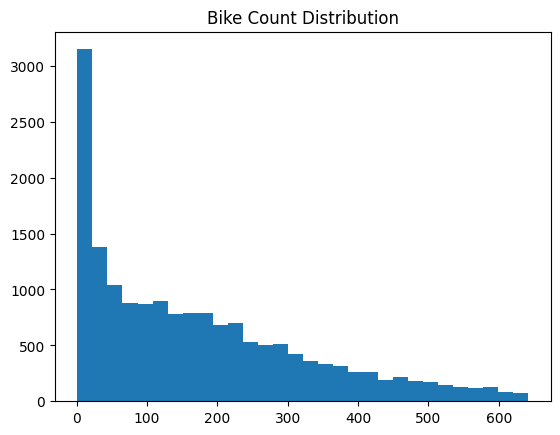

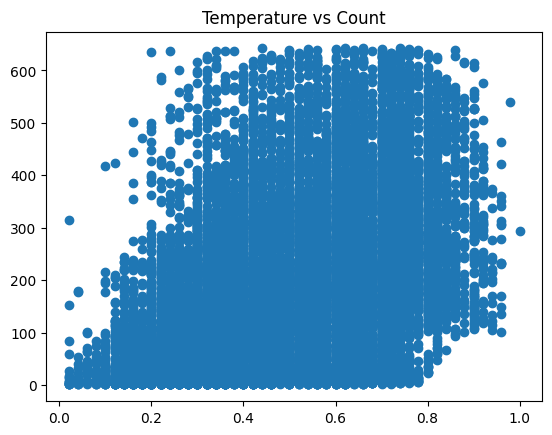

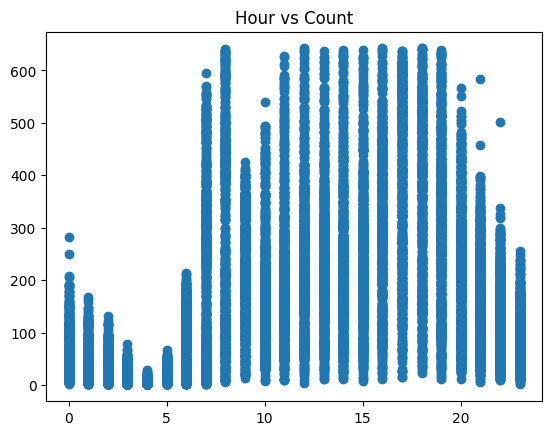

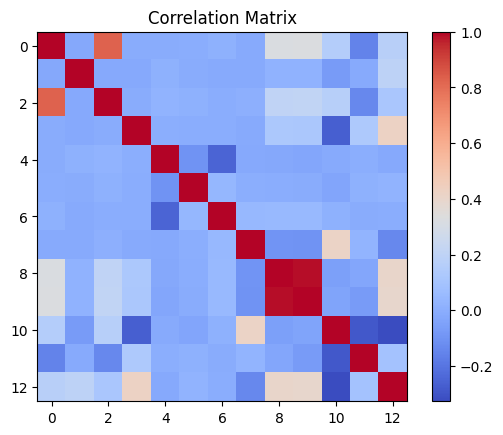

In [ ]:
plt.hist(df['cnt'], bins=30)
plt.title("Bike Count Distribution")
plt.show()

plt.scatter(df['temp'], df['cnt'])
plt.title("Temperature vs Count")
plt.show()

plt.scatter(df['hr'], df['cnt'])
plt.title("Hour vs Count")
plt.show()

plt.imshow(df.corr(), cmap='coolwarm')
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()


In [ ]:
X = df.drop('cnt', axis=1)
y = df['cnt']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)


In [ ]:
nn = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

nn_pred = nn.predict(X_test_scaled)

print("NN RMSE:", np.sqrt(mean_squared_error(y_test, nn_pred)))
print("NN R2:", r2_score(y_test, nn_pred))


NN RMSE: 41.58061826928278
NN R2: 0.925788052933456


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("LR RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("LR R2:", r2_score(y_test, lr_pred))


LR RMSE: 119.6075118682772
LR R2: 0.38594276458885124


In [ ]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_raw, y_train)

rf_pred = rf.predict(X_test_raw)

print("RF RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("RF R2:", r2_score(y_test, rf_pred))


RF RMSE: 37.76420877022279
RF R2: 0.9387857235430876


In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)

rf_grid.fit(X_train_raw, y_train)

print("Best Params:", rf_grid.best_params_)
print("Best CV Score:", rf_grid.best_score_)


Best Params: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: 0.900664951202214


In [ ]:
selector = SelectKBest(score_func=f_regression, k=8)

Xf_train = selector.fit_transform(X_train_raw, y_train)
Xf_test = selector.transform(X_test_raw)

print("Selected Features Mask:", selector.get_support())


Selected Features Mask: [ True  True  True  True False False False  True  True  True  True False]


In [ ]:
final_rf = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
final_rf.fit(Xf_train, y_train)

final_rf_pred = final_rf.predict(Xf_test)


In [ ]:
final_lr = LinearRegression()
final_lr.fit(Xf_train, y_train)

final_lr_pred = final_lr.predict(Xf_test)


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Final RF"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, final_rf_pred))
    ],
    "R2": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, final_rf_pred)
    ],
    "CV Score": ["-", "-", rf_grid.best_score_]
})

print(results)


               Model        RMSE        R2  CV Score
0  Linear Regression  119.607512  0.385943         -
1      Random Forest   37.764209  0.938786         -
2           Final RF   75.423684  0.755821  0.900665
